In [1]:
# Célula 1: Instalação das dependências
# Instalação de bibliotecas essenciais para AST, Embeddings, Busca Vetorial e o Modelo Mamba
!pip install -q langchain-core langchain-community langchain-text-splitters matplotlib sentence-transformers faiss-cpu networkx transformers torch accelerate --root-user-action=ignore
!pip install -U langchain-huggingface
# mas usaremos a implementação HuggingFace que é mais compatível para este exemplo.

In [2]:
import os
import ast
import glob
import networkx as nx
import torch
from typing import List, Dict, Any

# Novos imports para versões recentes da LangChain
from langchain_core.documents import Document # A classe Document foi movida
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
# Splitter pode estar em langchain.text_splitter ou langchain_text_splitters (nova)
try:
    from langchain_text_splitters import RecursiveCharacterTextSplitter
except ImportError:
    from langchain.text_splitter import RecursiveCharacterTextSplitter

from transformers import AutoTokenizer, AutoModelForCausalLM

# Configuração de dispositivo
# Se você tem PyTorch 2.9.1 com CUDA 12.4, a detecção de CUDA deve funcionar bem.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Imports realizados com sucesso! Rodando no dispositivo: {device}")

Imports realizados com sucesso! Rodando no dispositivo: cuda


In [3]:
# Célula 3: Criando um Projeto Simulado (Data Mock)
# Vamos criar alguns arquivos Python em uma pasta para simular um projeto real.

PROJECT_DIR = "meu_projeto_falso"
os.makedirs(PROJECT_DIR, exist_ok=True)

code_files = {
    "database.py": """
class Database:
    def __init__(self, connection_string):
        self.conn = connection_string
    
    def connect(self):
        print(f"Conectando a {self.conn}")
        return True

    def get_user(self, user_id):
        # Simula busca no banco
        return {"id": user_id, "username": "admin"}
""",
    "auth.py": """
from database import Database

class AuthManager:
    def __init__(self, db: Database):
        self.db = db

    def login(self, user_id, password):
        user = self.db.get_user(user_id)
        if user and password == "secret":
            print("Login realizado com sucesso")
            return True
        return False
""",
    "main.py": """
from auth import AuthManager
from database import Database

def main():
    db = Database("postgresql://localhost:5432")
    db.connect()
    
    auth = AuthManager(db)
    auth.login(1, "secret")

if __name__ == "__main__":
    main()
"""
}

# Escrevendo os arquivos no disco
for filename, content in code_files.items():
    with open(os.path.join(PROJECT_DIR, filename), "w") as f:
        f.write(content.strip())

print(f"Projeto simulado criado em: {PROJECT_DIR}")

Projeto simulado criado em: meu_projeto_falso


In [4]:
# Célula 4: Componente Simbólico (Análise Estática e Grafo de Dependência)
# Aqui lemos o código e criamos um grafo para entender "Quem chama quem".

class SymbolicCodeAnalyzer:
    def __init__(self):
        self.graph = nx.DiGraph()
        self.definitions = {} # Mapeia nome -> código fonte

    def parse_file(self, filepath):
        with open(filepath, "r") as f:
            code = f.read()
        
        try:
            tree = ast.parse(code)
            filename = os.path.basename(filepath)
            
            # Adiciona o arquivo como um nó base
            self.graph.add_node(filename, type="file", content=code)
            
            # Visita nós da AST
            for node in ast.walk(tree):
                if isinstance(node, (ast.FunctionDef, ast.ClassDef)):
                    node_name = node.name
                    # Mapeia definições para facilitar recuperação
                    self.definitions[node_name] = {
                        "file": filename,
                        "type": type(node).__name__,
                        "code": ast.get_source_segment(code, node)
                    }
                    
                    # Cria aresta do arquivo para a definição
                    self.graph.add_node(node_name, type="symbol")
                    self.graph.add_edge(filename, node_name, relation="defines")
                    
                    # Tenta encontrar chamadas dentro desta função (Lógica simplificada)
                    for subnode in ast.walk(node):
                        if isinstance(subnode, ast.Call):
                            if isinstance(subnode.func, ast.Name):
                                called_func = subnode.func.id
                                self.graph.add_edge(node_name, called_func, relation="calls")
                                
        except Exception as e:
            print(f"Erro ao parsear {filepath}: {e}")

    def get_related_symbols(self, symbol_name, depth=1):
        """Retorna dependências simbólicas (quem chama ou é chamado)."""
        if symbol_name not in self.graph:
            return []
        
        # Recupera vizinhos no grafo (contexto estrutural)
        related = list(self.graph.successors(symbol_name)) + list(self.graph.predecessors(symbol_name))
        return related

# Instanciando e populando o analisador simbólico
analyzer = SymbolicCodeAnalyzer()
for py_file in glob.glob(f"{PROJECT_DIR}/**/*.py", recursive=True):
    analyzer.parse_file(py_file)

print(f"Grafo simbólico construído com {analyzer.graph.number_of_nodes()} nós.")
# [Image of Network Graph] - Visualização mental: Arquivos conectando a Classes conectando a Funções

Grafo simbólico construído com 11 nós.


Gerando AST para AuthManager...


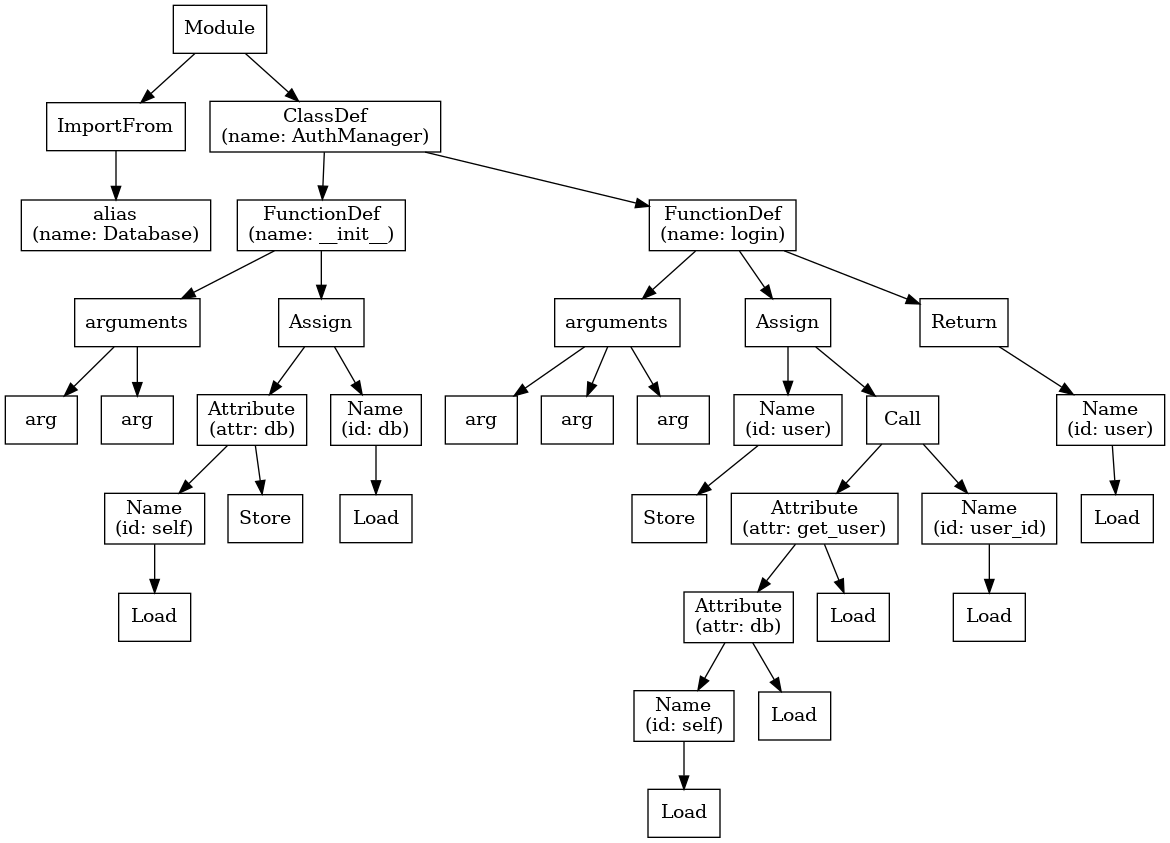

In [5]:
import ast
import graphviz
from IPython.display import Image, display

def plot_ast(code_string: str, filename: str = "ast_diagram"):
    """
    Gera um diagrama Graphviz da AST sem tentar abrir o arquivo no sistema
    (evitando o erro 'xdg-open').
    """
    try:
        tree = ast.parse(code_string)
    except Exception as e:
        print(f"Erro ao parsear o código: {e}")
        return None

    dot = graphviz.Digraph(comment='Abstract Syntax Tree', format='png')
    node_counter = 0

    def visit(node, parent_name=None):
        nonlocal node_counter
        node_id = str(node_counter)
        node_counter += 1
        
        node_label = type(node).__name__
        
        if hasattr(node, 'id'):
            node_label += f"\n(id: {node.id})"
        elif hasattr(node, 'name'):
            node_label += f"\n(name: {node.name})"
        elif hasattr(node, 'attr'):
            node_label += f"\n(attr: {node.attr})"
        elif isinstance(node, ast.Constant):
             node_label += f"\n(value: {repr(node.value)})"

        dot.node(node_id, node_label, shape='box')

        if parent_name is not None:
            dot.edge(parent_name, node_id)

        for field, value in ast.iter_fields(node):
            if isinstance(value, list):
                for item in value:
                    if isinstance(item, ast.AST):
                        visit(item, node_id)
            elif isinstance(value, ast.AST):
                visit(value, node_id)

    visit(tree)
    
    # *** CORREÇÃO APLICADA AQUI: view=False ***
    # Apenas salva o arquivo (não tenta visualizá-lo com comando externo)
    rendered_path = dot.render(filename, view=False, cleanup=True)
    
    return rendered_path

# Exemplo de código (use o seu código real aqui, se quiser)
code_to_plot = """
from database import Database

class AuthManager:
    def __init__(self, db):
        self.db = db

    def login(self, user_id, password):
        user = self.db.get_user(user_id)
        return user
"""

# Chama a função para plotar
print("Gerando AST para AuthManager...")
ast_plot_path = plot_ast(code_to_plot, filename="AuthManager_AST")

# Exibe o arquivo gerado (PNG) diretamente no output do Jupyter
if ast_plot_path:
    # O arquivo gerado é "AuthManager_AST.png" (ou outro formato se 'format' foi alterado)
    display(Image(filename="AuthManager_AST.png"))

Plotando Grafo de Dependência do Projeto com 11 nós e 14 arestas.


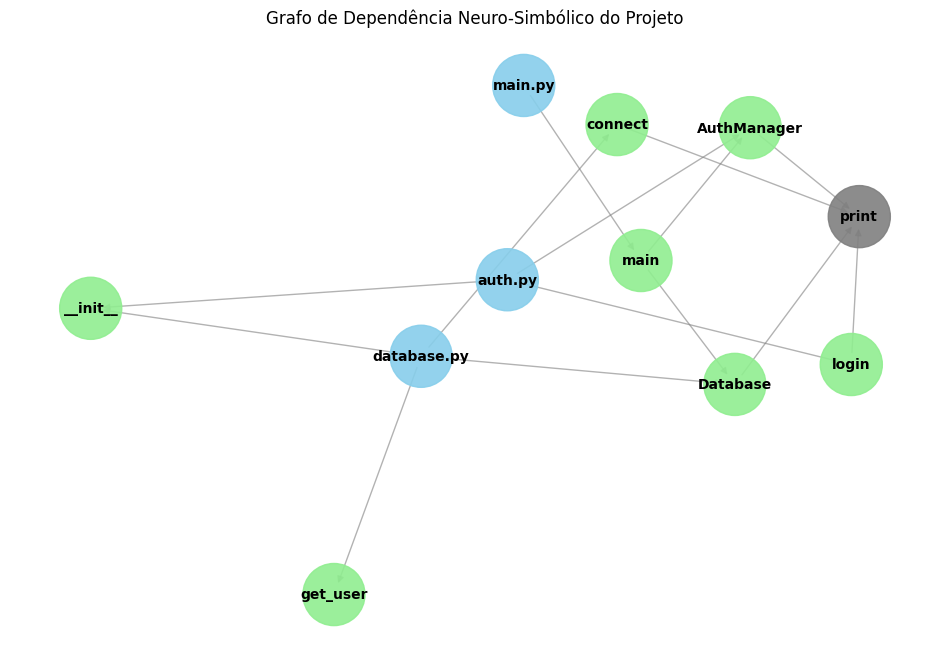


Legenda:
- Nós Azuis (skyblue): Arquivos Python (ex: main.py)
- Nós Verdes (lightgreen): Símbolos (Classes ou Funções, ex: login, Database)


In [6]:
import matplotlib.pyplot as plt
import networkx as nx
import os

# Acessa o grafo que foi construído pelo SymbolicCodeAnalyzer
project_graph = analyzer.graph

print(f"Plotando Grafo de Dependência do Projeto com {project_graph.number_of_nodes()} nós e {project_graph.number_of_edges()} arestas.")

# Configuração de plotagem
plt.figure(figsize=(12, 8))

# Define o layout do grafo (spring_layout é bom para grafos pequenos)
# Outras opções são: circular_layout, shell_layout
pos = nx.spring_layout(project_graph, k=0.8, iterations=50) 

# Extrai rótulos e cores com base no tipo de nó (arquivo vs. símbolo)
node_colors = []
node_labels = {}
for node in project_graph.nodes:
    node_type = project_graph.nodes[node].get('type', 'unknown')
    
    if node_type == 'file':
        node_colors.append('skyblue')
    elif node_type == 'symbol':
        node_colors.append('lightgreen')
    else:
        node_colors.append('gray')
        
    # Usa apenas o nome do nó como rótulo
    node_labels[node] = node

# 1. Desenha os nós (pontos)
nx.draw_networkx_nodes(project_graph, pos, node_color=node_colors, node_size=2000, alpha=0.9)

# 2. Desenha as arestas (conexões)
nx.draw_networkx_edges(project_graph, pos, edge_color='gray', width=1, alpha=0.6)

# 3. Desenha os rótulos
nx.draw_networkx_labels(project_graph, pos, labels=node_labels, font_size=10, font_weight='bold')

plt.title("Grafo de Dependência Neuro-Simbólico do Projeto")
plt.axis('off')
plt.show()

# Legenda:
print("\nLegenda:")
print("- Nós Azuis (skyblue): Arquivos Python (ex: main.py)")
print("- Nós Verdes (lightgreen): Símbolos (Classes ou Funções, ex: login, Database)")

In [7]:
# Célula 5: Componente Neural (Indexação Vetorial) - Código inalterado

# 1. Carregar documentos
documents = []
for py_file in glob.glob(f"{PROJECT_DIR}/*.py"):
    with open(py_file, "r") as f:
        content = f.read()
        documents.append(Document(page_content=content, metadata={"source": py_file}))

# 2. Splitter otimizado para código
text_splitter = RecursiveCharacterTextSplitter.from_language(
    language="python", chunk_size=500, chunk_overlap=50
)
splitted_docs = text_splitter.split_documents(documents)

# 3. Criar Embeddings (Agora importado do pacote correto)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# 4. Criar Vector Store
vector_store = FAISS.from_documents(splitted_docs, embeddings)
retriever_neural = vector_store.as_retriever(search_kwargs={"k": 3})

print("Índice Neural (FAISS) criado com sucesso.")

Índice Neural (FAISS) criado com sucesso.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Iniciando a redução de dimensionalidade (t-SNE) para visualização...


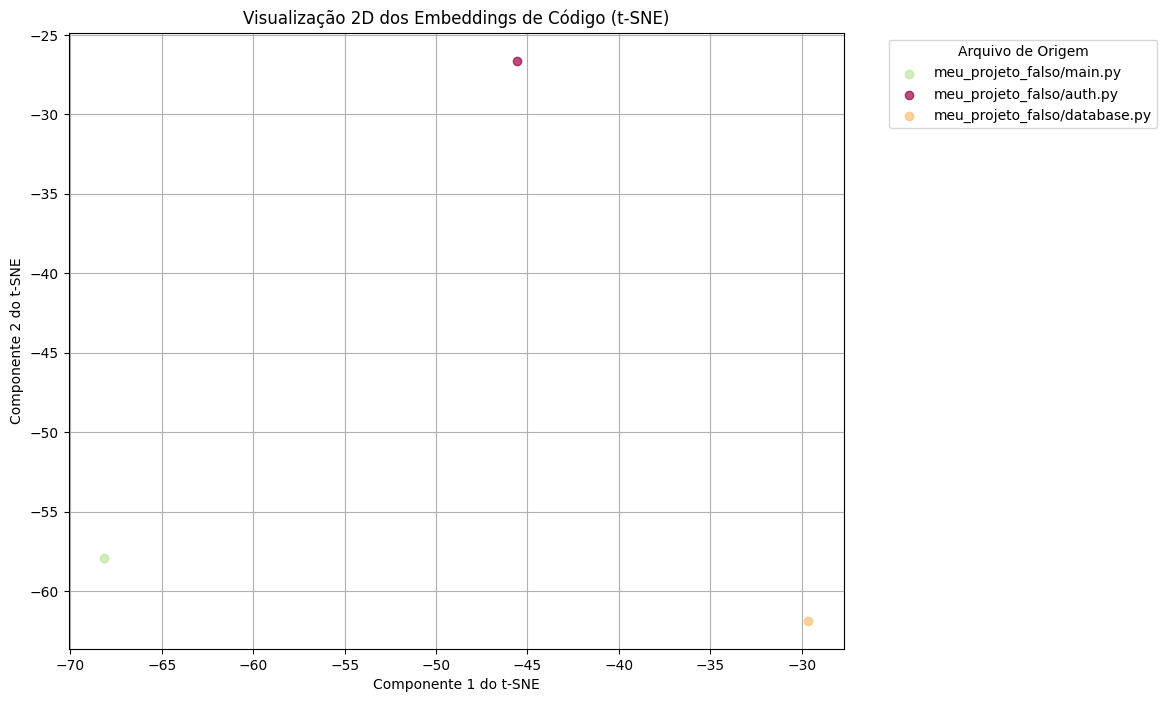


Os clusters no gráfico mostram quais trechos de código (chunks) são semanticamente mais próximos no espaço vetorial.


In [8]:
# Célula 5.5: Visualização do Espaço Vetorial (Neural Indexing)

!pip install -q scikit-learn --root-user-action=ignore
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

print("Iniciando a redução de dimensionalidade (t-SNE) para visualização...")

# 1. Extrair os vetores e metadados
# O FAISS armazena os vetores em um objeto subjacente (index.reconstruct_n)
# mas é mais fácil extrair os vetores diretamente do FAISS se ele for simples.

# Iremos pegar os vetores diretamente da store
all_embeddings = vector_store.index.reconstruct_n(0, len(splitted_docs))

# Extrair os rótulos (nomes dos arquivos)
labels = [doc.metadata['source'] for doc in splitted_docs]

# 2. Aplicar t-SNE (Reduz para 2 dimensões)
# t-SNE é bom para preservar a estrutura local dos clusters
tsne = TSNE(n_components=2, random_state=42, perplexity=2)

embeddings_2d = tsne.fit_transform(all_embeddings)

# 3. Plotar os resultados
plt.figure(figsize=(10, 8))

# Mapeamento para cores únicas por arquivo
unique_labels = sorted(list(set(labels)))
label_to_color = {label: plt.colormaps.get_cmap('Spectral')(i/len(unique_labels)) 
                  for i, label in enumerate(unique_labels)}

# Plotar cada ponto, colorindo pelo arquivo de origem
for i, (x, y) in enumerate(embeddings_2d):
    file_label = labels[i]
    plt.scatter(x, y, color=label_to_color[file_label], label=file_label if file_label not in plt.gca().get_legend_handles_labels()[1] else "", alpha=0.7)
    
    # Adicionar rótulos (opcional, para grafos pequenos)
    # plt.annotate(file_label.split('/')[-1].replace('.py', ''), (x, y), textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8)


plt.title('Visualização 2D dos Embeddings de Código (t-SNE)')
plt.xlabel('Componente 1 do t-SNE')
plt.ylabel('Componente 2 do t-SNE')
plt.legend(title="Arquivo de Origem", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

print("\nOs clusters no gráfico mostram quais trechos de código (chunks) são semanticamente mais próximos no espaço vetorial.")

In [9]:
# Célula 6: Motor de Recuperação Híbrida (CORRIGIDA)
from typing import List, Set

class HybridRetriever:
    """Combina busca vetorial (Neural) e análise de grafo (Simbólica) para contexto."""
    def __init__(self, neural_retriever, symbolic_analyzer):
        self.neural = neural_retriever
        self.symbolic = symbolic_analyzer

    def retrieve(self, query: str) -> str:
        # Passo 1: Busca Neural (encontra trechos semanticamente relevantes)
        
        # *** CORREÇÃO APLICADA AQUI: Usando .invoke(query) em vez de .get_relevant_documents(query) ***
        docs = self.neural.invoke(query)
        
        context_snippets: Set[str] = set()
        found_symbols: List[str] = []

        # Adiciona contexto neural e identifica símbolos no texto recuperado
        for doc in docs:
            # Adiciona o chunk recuperado ao contexto
            context_snippets.add(f"--- FILE: {doc.metadata.get('source', 'unknown')} ---\n{doc.page_content}")
            
            # Heurística de identificação de símbolos:
            for symbol in self.symbolic.definitions:
                if symbol in doc.page_content:
                    found_symbols.append(symbol)

        # Passo 2: Expansão Simbólica (Graph Traversal)
        processed_symbols = set(found_symbols)
        
        for symbol in processed_symbols:
            related = self.symbolic.get_related_symbols(symbol)
            
            for rel in related:
                if rel in self.symbolic.definitions and rel not in processed_symbols:
                    def_info = self.symbolic.definitions[rel]
                    
                    snippet = f"--- DEFINITION (Symbolic Context - Dependency of {symbol}): {rel} ---\n{def_info['code']}"
                    context_snippets.add(snippet)
                    processed_symbols.add(rel)

        return "\n\n".join(context_snippets)

# Instanciando o Motor Híbrido
hybrid_rag = HybridRetriever(retriever_neural, analyzer)

print("Motor de Recuperação Híbrida instanciado. Pronto para combinar busca Neural e Simbólica.")

Motor de Recuperação Híbrida instanciado. Pronto para combinar busca Neural e Simbólica.


In [33]:
# Célula 7: Modelo de Inferência (Mamba)
# Usaremos uma versão pequena do Mamba compatível com HuggingFace para caber na memória do exemplo.
# Para produção, use 'state-spaces/mamba-2.8b-hf' ou maior.

model_id = "state-spaces/mamba-130m-hf" # Versão tiny para teste rápido.

print(f"Carregando modelo Mamba: {model_id}...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id).to(device)

def generate_response(prompt, context):
    full_prompt = f"""
### INSTRUCTION:
Você é um especialista em Python. Use o contexto abaixo para responder à solicitação.
Analise as dependências e a lógica.

### CONTEXT:
{context}

### REQUEST:
{prompt}

### CODE SOLUTION:
"""
    inputs = tokenizer(full_prompt, return_tensors="pt").to(device)
    
    # Geração
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=200, 
            do_sample=True, 
            temperature=0.2 # Baixa temperatura para código mais preciso
        )
    
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print("Modelo Mamba carregado.")

Carregando modelo Mamba: state-spaces/mamba-130m-hf...
Modelo Mamba carregado.


In [44]:
# Célula 8: Execução do RAG Neuro-Simbólico
# Prompt: Pedido de alteração no código

user_prompt = "Modifique a função de login para printar se a senha estiver errada."

# 1. Recuperação Híbrida
retrieved_context = hybrid_rag.retrieve(user_prompt)

print("="*20 + " CONTEXTO RECUPERADO (HÍBRIDO) " + "="*20)
print(retrieved_context[:1000] + "...") # Printando apenas os primeiros 1000 chars

# 2. Geração com Mamba
print("\n" + "="*20 + " RESPOSTA DO MODELO MAMBA " + "="*20)
response = generate_response(user_prompt, retrieved_context)

# Limpeza visual da resposta para mostrar apenas a solução gerada
solution_start = response.find("### CODE SOLUTION:")
print(response[solution_start:-1])


==================== CONTEXTO RECUPERADO (HÍBRIDO) ====================
--- FILE: meu_projeto_falso/main.py ---
from auth import AuthManager
from database import Database

def main():
    db = Database("postgresql://localhost:5432")
    db.connect()

    auth = AuthManager(db)
    auth.login(1, "secret")

if __name__ == "__main__":
    main()

--- FILE: meu_projeto_falso/database.py ---
class Database:
    def __init__(self, connection_string):
        self.conn = connection_string

    def connect(self):
        print(f"Conectando a {self.conn}")
        return True

    def get_user(self, user_id):
        # Simula busca no banco
        return {"id": user_id, "username": "admin"}

--- FILE: meu_projeto_falso/auth.py ---
from database import Database

class AuthManager:
    def __init__(self, db: Database):
        self.db = db

    def login(self, user_id, password):
        user = self.db.get_user(user_id)
        if user and password == "secret":
            print("Login realizado